# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [1]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2002 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


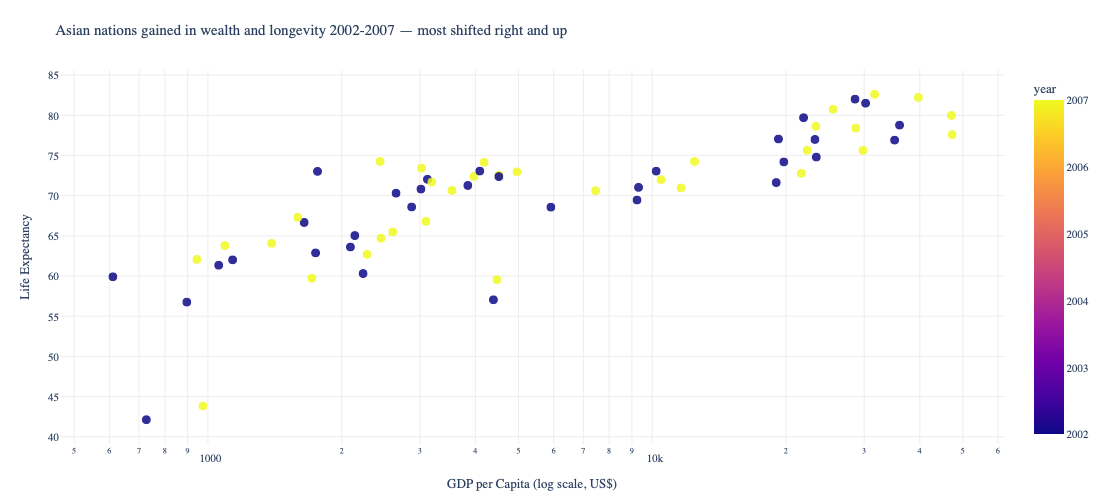

In [16]:
# Task 1
asia = df[(df['continent'] == 'Asia') & (df['year'].isin([2002, 2007]))]
asia.loc[:, 'year'] = asia.loc[:, 'year'].astype(int)
fig = px.scatter(
    data_frame=asia,
    x='gdpPercap',
    y='lifeExp',
    color='year',                         
    hover_name='country',
    hover_data={'year': False},
    title='Asian nations gained in wealth and longevity 2002-2007 — most shifted right and up',
    labels={'gdpPercap': 'GDP per Capita (log scale, US$)', 'lifeExp': 'Life Expectancy'},
    color_discrete_map={'2002': '#AAAAAA', '2007': '#2E75B6'},  
    log_x=True,
    height=500
)

fig.update_traces(
    marker=dict(size=9, opacity=0.85)
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Calibri', size=11),
    legend=dict(title='Year', orientation='h', y=1.08),
    margin=dict(l=60, r=40, t=70, b=40),
)

fig.update_xaxes(gridcolor='#EEEEEE')
fig.update_yaxes(gridcolor='#EEEEEE')

fig.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


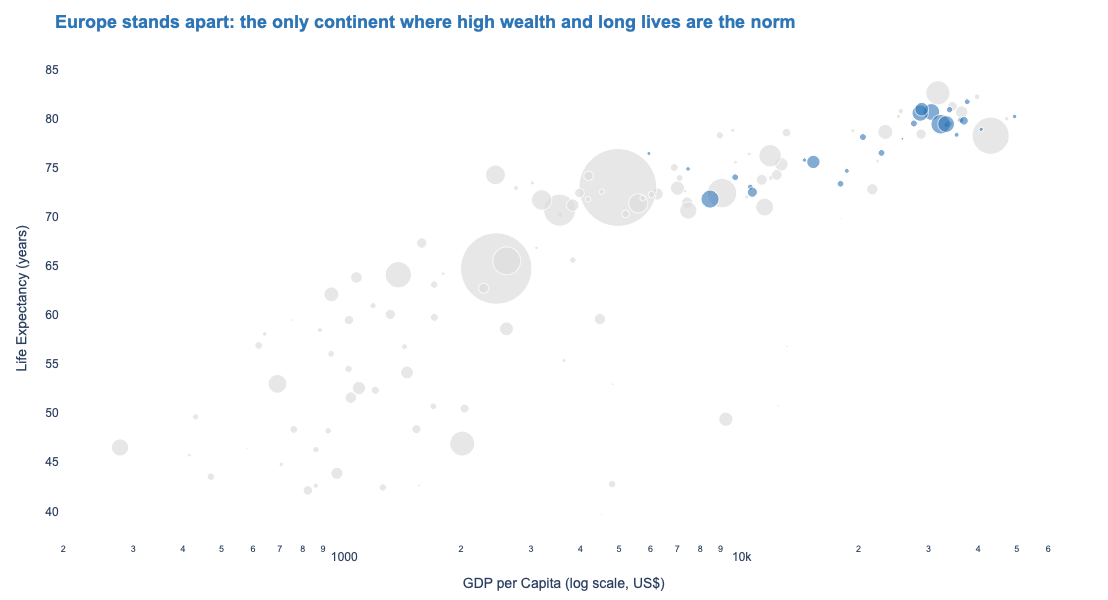

In [23]:
# Task 2
highlight = 'Europe'
df07 = df.loc[df['year'] == 2007].copy()
df07['color_role'] = df07['continent'].apply(lambda c: 'Europe' if c == highlight else 'Other')

fig = px.scatter(
    data_frame=df07,
    x='gdpPercap',
    y='lifeExp',
    size='pop',                    
    color='color_role',
    hover_name='country',
    title='<b>Europe stands apart: the only continent where high wealth and long lives are the norm</b>',
    labels={'gdpPercap': 'GDP per Capita (log scale, US$)', 'lifeExp': 'Life Expectancy (years)', 'pop': 'Population'},
    color_discrete_map={'Europe': '#2E75B6', 'Other': '#DDDDDD'},
    category_orders={'color_role': ['Other', 'Europe']},
    log_x=True,
    size_max=55,
    height=600, width=1100
)
fig.update_traces(
    selector=dict(name='Europe'),
    marker=dict(opacity=0.6))

fig.update_layout(
    showlegend=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=60, r=40, t=55, b=40),
    title=dict(font=dict(color='#2E75B6', size=18)))

fig.show()
